In [50]:
import random
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [51]:
X,y = make_classification(
    n_features=5,
    n_redundant=0,
    n_informative=5,
    n_clusters_per_class=1
)

In [52]:
df = pd.DataFrame(X, columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y

print(df.shape)
print(df.head())

(100, 6)
       col1      col2      col3      col4      col5  target
0 -1.124222  0.614125 -2.207529 -0.639162  0.953858       1
1  2.980663 -0.220487 -2.357703 -0.374946 -2.219426       0
2 -0.855748  0.909930 -0.784013 -0.447616 -0.237537       1
3 -2.138951  0.980322 -2.871095  0.845499 -1.155120       1
4 -0.668711  1.074388 -0.709274 -0.557642  0.194520       1


In [53]:
# Function for Row Sampling

def sample_rows(df, percent):
    return df.sample(int(percent*df.shape[0]), replace=True)

In [54]:
# Function for Feature Sampling

def sample_features(df, percent):
    cols = random.sample(df.columns.tolist()[:-1], int(percent*(df.shape[1]-1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

In [55]:
# Function for Combined Sampling

def combined_sampling(df, row_percent, col_percent):
    new_df = sample_rows(df, row_percent)
    return sample_features(new_df, col_percent)

In [56]:
df1 = combined_sampling(df, 0.5, 0.5)
df2 = combined_sampling(df, 0.5, 0.5)
df3 = combined_sampling(df, 0.5, 0.5)

C:\Users\ACER\AppData\Local\Temp\ipykernel_2696\3709425174.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\ACER\AppData\Local\Temp\ipykernel_2696\3709425174.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\ACER\AppData\Local\Temp\ipykernel_2696\3709425174.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

In [57]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col3', 'col2', 'target'], dtype='object')
Index(['col2', 'col3', 'target'], dtype='object')
Index(['col3', 'col2', 'target'], dtype='object')


In [58]:
df1.head()

,col3,col2,target
21,-0.002448,-1.284711,0
64,0.760306,0.675064,1
15,-0.614129,-2.193161,0
14,-0.307970,-0.497730,0
69,-2.813843,-0.004579,1


In [59]:
df2.head()

,col2,col3,target
28,-1.540587,-1.832501,0
88,-1.191441,1.080645,0
58,-2.763578,0.390264,0
57,0.009582,-2.357184,1
84,-2.332970,0.568766,0


In [60]:
df3.head()

,col3,col2,target
52,0.965188,-1.233025,0
78,-3.114409,-0.987191,1
99,-1.194639,-0.227358,0
45,-0.056468,1.446109,1
32,0.375177,-2.481881,0


In [61]:
from sklearn.tree import DecisionTreeClassifier

clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [62]:
clf1.fit(df1.iloc[:, 0:2], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:2], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:2], df3.iloc[:, -1])

DecisionTreeClassifier()

In [63]:
from sklearn.tree import plot_tree

[Text(0.5769230769230769, 0.9285714285714286, 'x[1] <= -0.009\ngini = 0.487\nsamples = 50\nvalue = [29.0, 21.0]'),
 Text(0.3076923076923077, 0.7857142857142857, 'x[0] <= -2.395\ngini = 0.219\nsamples = 32\nvalue = [28, 4]'),
 Text(0.4423076923076923, 0.8571428571428572, 'True  '),
 Text(0.15384615384615385, 0.6428571428571429, 'x[0] <= -2.781\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.23076923076923078, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.46153846153846156, 0.6428571428571429, 'x[0] <= -1.2\ngini = 0.128\nsamples = 29\nvalue = [27, 2]'),
 Text(0.38461538461538464, 0.5, 'x[0] <= -1.208\ngini = 0.231\nsamples = 15\nvalue = [13, 2]'),
 Text(0.3076923076923077, 0.35714285714285715, 'x[1] <= -0.613\ngini = 0.133\nsamples = 14\nvalue = [13, 1]'),
 Text(0.23076923076923078, 0.21428571428571427, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.38461538461538464, 0.21428571428571427, '

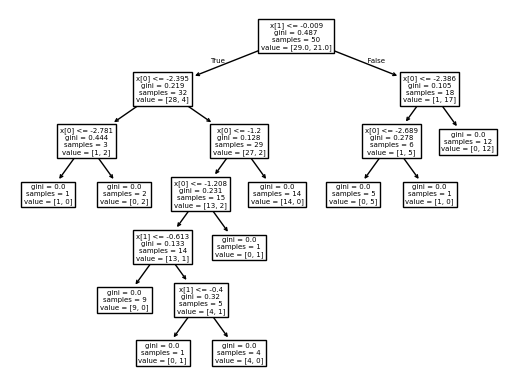

In [64]:
plot_tree(clf1)

[Text(0.6, 0.9375, 'x[0] <= 0.324\ngini = 0.461\nsamples = 50\nvalue = [32, 18]'),
 Text(0.4, 0.8125, 'x[1] <= -1.929\ngini = 0.239\nsamples = 36\nvalue = [31, 5]'),
 Text(0.5, 0.875, 'True  '),
 Text(0.3, 0.6875, 'x[0] <= -0.002\ngini = 0.494\nsamples = 9\nvalue = [4, 5]'),
 Text(0.2, 0.5625, 'x[1] <= -3.484\ngini = 0.49\nsamples = 7\nvalue = [4, 3]'),
 Text(0.1, 0.4375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3, 0.4375, 'x[0] <= -0.4\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.2, 0.3125, 'x[1] <= -2.663\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.1, 0.1875, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3, 0.1875, 'x[1] <= -2.103\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4, 0.3125, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.4, 0.5625, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.5, 0.6875, 'gini = 

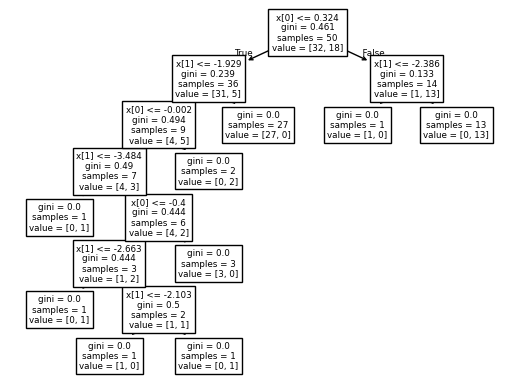

In [65]:
plot_tree(clf2)

[Text(0.5, 0.875, 'x[1] <= 0.289\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.25, 0.625, 'x[0] <= -2.08\ngini = 0.337\nsamples = 28\nvalue = [22, 6]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.375, 0.375, 'gini = 0.0\nsamples = 22\nvalue = [22, 0]'),
 Text(0.75, 0.625, 'x[0] <= -2.386\ngini = 0.165\nsamples = 22\nvalue = [2, 20]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[1] <= 1.08\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.75, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.875, 0.375, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]')]

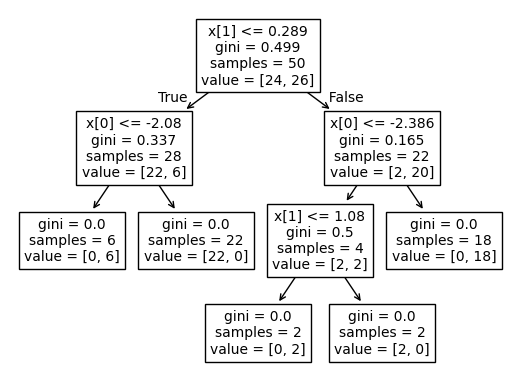

In [66]:
plot_tree(clf3)

In [67]:
clf1.predict(np.array([-1.042498, -0.064323]).reshape(1,2))

C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [68]:
clf2.predict(np.array([-1.042498, -0.064323]).reshape(1,2))

C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [69]:
clf3.predict(np.array([-1.042498, -0.064323]).reshape(1,2))

C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [70]:
df.sample(14, replace=True)

,col1,col2,col3,col4,col5,target
57,-1.440984,0.009582,-2.357184,-1.173796,-0.971846,1
22,-1.220727,0.671174,-0.250587,-1.880961,0.764404,1
20,-0.092563,-1.135246,0.148857,-2.295185,0.976254,0
0,-1.124222,0.614125,-2.207529,-0.639162,0.953858,1
62,-1.354684,2.378214,0.875690,-0.318563,2.964158,1
8,-2.377503,1.044050,-0.409351,-1.282899,0.056796,1
82,-1.116387,-2.081234,-0.102202,-1.570882,0.642579,0
26,1.317946,-1.828696,-1.659464,-0.615533,-1.837125,0
90,1.487884,0.232668,-0.476782,-1.661203,-3.551773,0
17,1.750601,-0.031253,-1.119418,-1.184723,0.956186,0
